In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('../Dataset/fuel_prices_1970_2026.csv')
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             675 non-null    str    
 1   Crude_Oil_Price  675 non-null    float64
dtypes: float64(1), str(1)
memory usage: 10.7 KB


In [2]:
print("\nJumlah Missing Value:\n", df.isnull().sum())


Jumlah Missing Value:
 Date               0
Crude_Oil_Price    0
dtype: int64


In [21]:
df.isnull().any()

Date               False
Crude_Oil_Price    False
dtype: bool

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
print(df.head())

        Date  Crude_Oil_Price
0 1970-01-01             1.21
1 1970-02-01             1.21
2 1970-03-01             1.21
3 1970-04-01             1.21
4 1970-05-01             1.21


In [8]:
Q1 = df['Crude_Oil_Price'].quantile(0.25)
Q3 = df['Crude_Oil_Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Crude_Oil_Price'] < lower_bound) | (df['Crude_Oil_Price'] > upper_bound)]
print(f"\nJumlah outlier yang terdeteksi: {len(outliers)}")


Jumlah outlier yang terdeteksi: 2


In [12]:
print(outliers[['Date', 'Crude_Oil_Price']])

          Date  Crude_Oil_Price
461 2008-06-01       131.521111
462 2008-07-01       132.825184


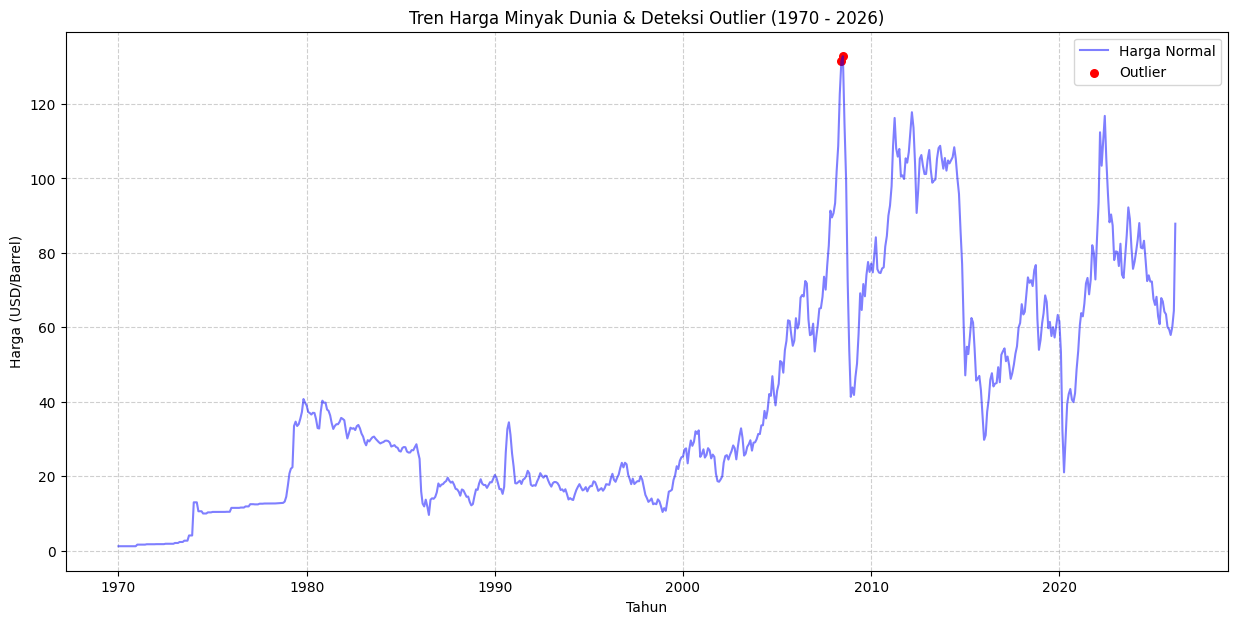

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 7))

# Plot data asli
plt.plot(df['Date'], df['Crude_Oil_Price'], label='Harga Normal', color='blue', alpha=0.5)

# Plot titik outlier
plt.scatter(outliers['Date'], outliers['Crude_Oil_Price'], color='red', label='Outlier', s=30)

plt.title('Tren Harga Minyak Dunia & Deteksi Outlier (1970 - 2026)')
plt.xlabel('Tahun')
plt.ylabel('Harga (USD/Barrel)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x1b0ade40c20>,
 'caps': [<matplotlib.lines.Line2D at 0x1b0ade40ec0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1b0ade40ad0>],
 'medians': [<matplotlib.lines.Line2D at 0x1b0ade41160>],
 'fliers': [<matplotlib.lines.Line2D at 0x1b0ade412b0>],
 'means': []}

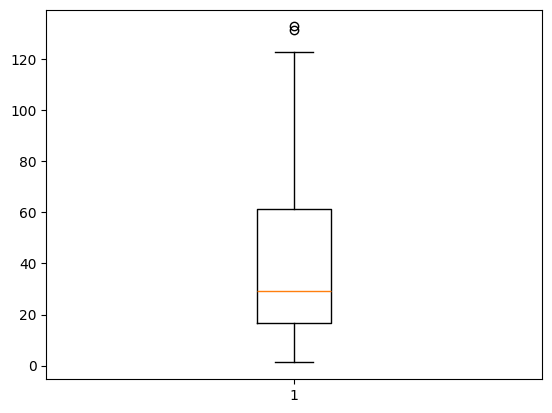

In [14]:
plt.boxplot(df['Crude_Oil_Price'])

In [26]:
# Encoding data 

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Fungsi untuk menentukan era
def klasifikasi_era(year):
    if 1970 <= year <= 1985:
        return "Era Of Oil Shocks"
    elif 1986 <= year <= 2003:
        return "Era Of Stability & Globalization"
    elif 2004 <= year <= 2014:
        return "Age of Peaks"
    elif 2015 <= year <= 2020:
        return "Era Of CommodityTransition"
    else:
        return "The Modern Era / Future Projection" # Untuk 2021 - 2026

# Tambahkan kolom baru
df['Era'] = df['Year'].apply(klasifikasi_era)

# Cek hasilnya
print(df.tail())

          Date  Crude_Oil_Price  Year                                 Era
670 2025-11-01            59.46  2025  The Modern Era / Future Projection
671 2025-12-01            57.95  2025  The Modern Era / Future Projection
672 2026-01-01            60.04  2026  The Modern Era / Future Projection
673 2026-02-01            64.47  2026  The Modern Era / Future Projection
674 2026-03-01            87.84  2026  The Modern Era / Future Projection


In [27]:
df.to_csv('../Dataset/fuel_prices_1970_2026_cleaned_and_classified.csv', index=False)